In [1]:
import math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from General_LR import compute_model, compute_cost, compute_gradient, gradient_descent

# Univariate Linear Regression

| <img width=70/> <br />  Notation  <img width=70/> | Description<img width=350/>| Python (if applicable) |
|: ------------|: ------------------------------------------------------------||
| $a$ | scalar, non bold                                                      ||
| $\mathbf{a}$ | vector, bold                                                      ||
| **Regression** |         |    |     |
|  $\mathbf{x}$ | Training Example feature values (in this lab - Size (1000 sqft))  | `x_train` |   
|  $\mathbf{y}$  | Training Example  targets (in this lab Price (1000s of dollars))  | `y_train` 
|  $x^{(i)}$, $y^{(i)}$ | $i_{th}$Training Example | `x_i`, `y_i`|
| m | Number of training examples | `m`|
|  $w$  |  parameter: weight                                 | `w`    |
|  $b$           |  parameter: bias                                           | `b`    |     
| $f_{w,b}(x^{(i)})$ | The result of the model evaluation at $x^{(i)}$ parameterized by $w,b$: $f_{w,b}(x^{(i)}) = wx^{(i)}+b$  | `f_wb` | 

In [2]:
x_train = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_train = np.array([300.0, 500.0, 700, 900, 1100])
df = pd.DataFrame({"sizes": x_train, 
                   "prices": y_train})
df

,sizes,prices
0,1.0,300.0
1,2.0,500.0
2,3.0,700.0
3,4.0,900.0
4,5.0,1100.0


#### array.shape

In [3]:
m = x_train.shape
print(f"x_train.shape: {m}")
print(f"Number of training examples is: {m[0]}")
# OR
print(f"Number of training examples is: {len(x_train)}")

x_train.shape: (5,)
Number of training examples is: 5
Number of training examples is: 5


### Plot the data points

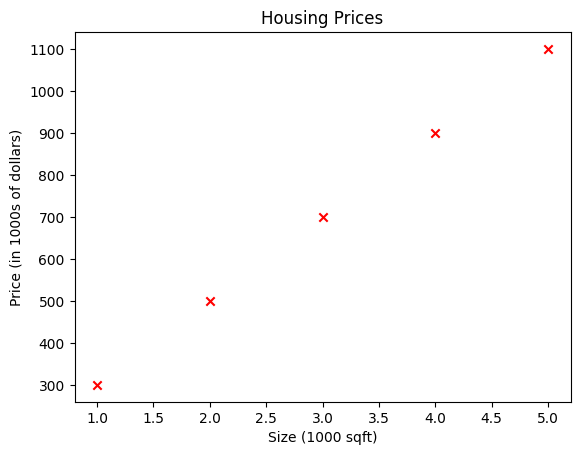

In [4]:
plt.scatter(x_train, y_train, marker='x', c='r')
plt.title("Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.show()

## Play with w, b to find the best one

In [5]:
w = 200
b = 100

### Model

In [6]:
model_output = compute_model(x_train, w, b)
print(model_output)

[ 300.  500.  700.  900. 1100.]


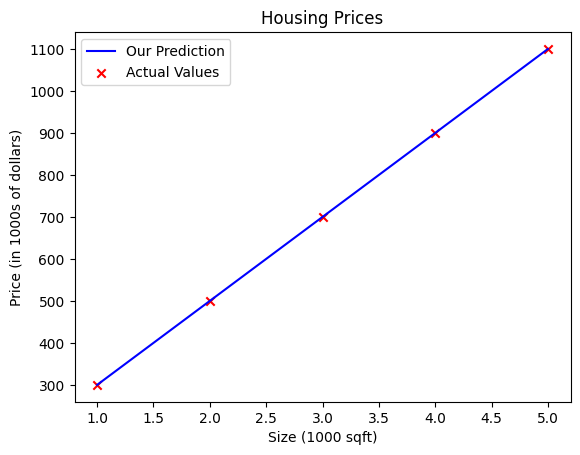

In [7]:
plt.plot(x_train, model_output, c='blue', label = 'Our Prediction')
plt.scatter(x_train, y_train, marker='x', c='r', label = 'Actual Values')

plt.title("Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')

plt.legend()
plt.show()

# Loss Function

$$ \text {cost} = \sum\limits_{i = 0}^{m-1} (w \cdot x^{(i)} + b) - y^{(i)})^2$$ 
$$ \text {total_cost = } \frac{1}{2m}  \text {cost}$$

In [8]:
model_cost = compute_cost(x_train, y_train, w, b, model=compute_model)
model_cost

0.0

# Gradient

$$ \frac{\text{dj}}{\text{dw}} = \frac{1}{m} \sum\limits_{i=0}^{m-1} ((w \cdot x^{(i)} + b) - y^{(i)}) \cdot {x^{(i)}} $$
$$ \frac{\text{dj}}{\text{db}} = \frac{1}{m} \sum\limits_{i=0}^{m-1} ((w \cdot x^{(i)} + b) - y^{(i)}) $$

# Gradient Descent

$$ \text{W} = \text{W} - \alpha \cdot \frac{\text{dj}}{\text{dW}}$$
$$ \text{b} = \text{b} - \alpha \cdot \frac{\text{dj}}{\text{db}}$$

In [9]:
w_final, b_final, J_hist, p_hist = gradient_descent(x = np.array([1.0, 2.0]),
                     y = np.array([300.0, 500.0]),
                     w = 0,
                     b = 0,
                     alpha = 1.0e-2,
                     num_iters = 10000)

print(f"(w,b) found by gradient descent: ({w_final:8.4f}, {b_final:8.4f})")

Iteration    0: Cost 79274.81
Iteration 1000: Cost 3.41
Iteration 2000: Cost 0.79
Iteration 3000: Cost 0.18
Iteration 4000: Cost 0.04
Iteration 5000: Cost 0.01
Iteration 6000: Cost 0.00
Iteration 7000: Cost 0.00
Iteration 8000: Cost 0.00
Iteration 9000: Cost 0.00
Iteration 10000: Cost 0.00
(w,b) found by gradient descent: (199.9929, 100.0116)


In [10]:
# In 4,000 iteration we obtain the minimum

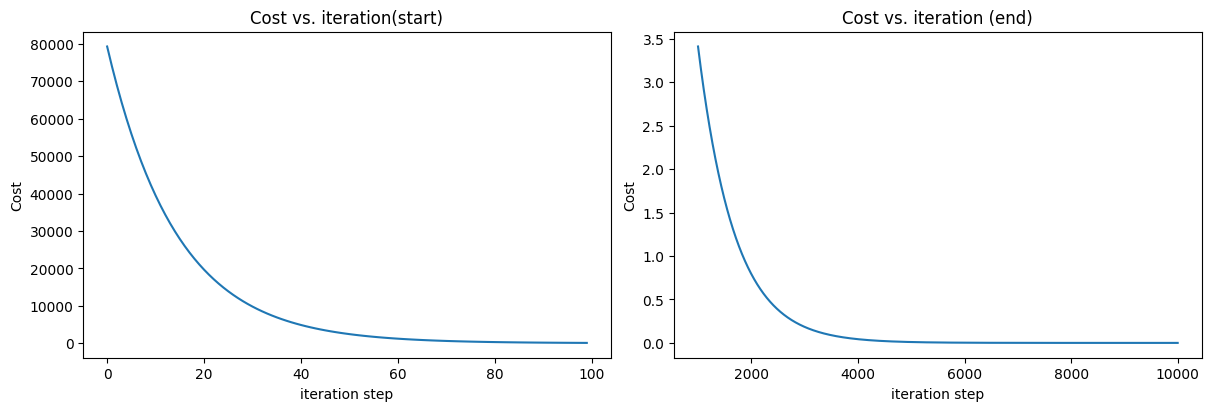

In [11]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)")
ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')
ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')
ax2.set_xlabel('iteration step') 
plt.show()

In [12]:
# predictions
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction 300.0 Thousand dollars
1200 sqft house prediction 340.0 Thousand dollars
2000 sqft house prediction 500.0 Thousand dollars


In [13]:
# Increased Learning Rate

w_final, b_final, J_hist, p_hist = gradient_descent(x = np.array([1.0, 2.0]),
                     y = np.array([300.0, 500.0]),
                     w = 0,
                     b = 0,
                     alpha = 5.0e-1,
                     num_iters = 1000)

print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 43281.25
Iteration  100: Cost 0.01
Iteration  200: Cost 0.00
Iteration  300: Cost 0.00
Iteration  400: Cost 0.00
Iteration  500: Cost 0.00
Iteration  600: Cost 0.00
Iteration  700: Cost 0.00
Iteration  800: Cost 0.00
Iteration  900: Cost 0.00
Iteration 1000: Cost 0.00
(w,b) found by gradient descent: (200.0000,100.0000)


In [14]:
# In 900 iteration we obtain the minimum

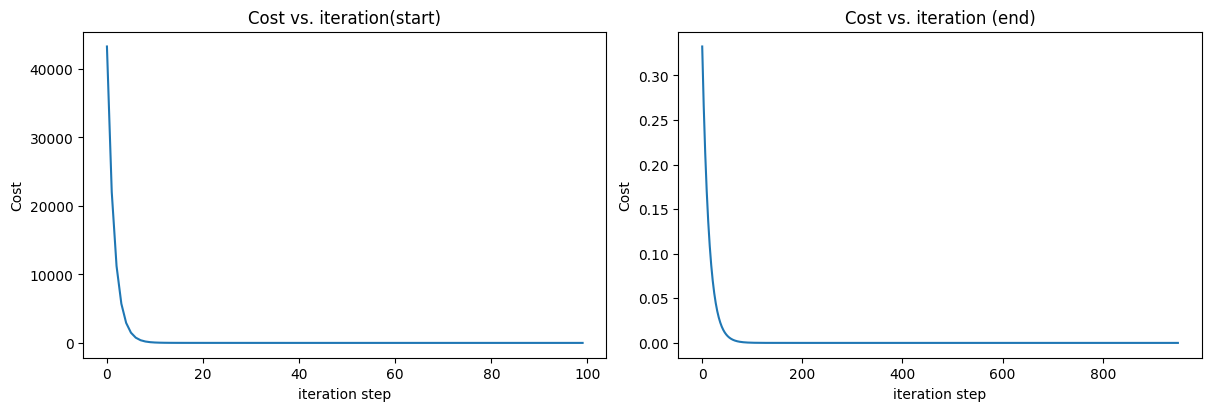

In [15]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(np.arange(len(J_hist[50:])), J_hist[50:])
ax1.set_title("Cost vs. iteration(start)")
ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')
ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')
ax2.set_xlabel('iteration step') 
plt.show()

In [16]:
# predictions
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction 300.0 Thousand dollars
1200 sqft house prediction 340.0 Thousand dollars
2000 sqft house prediction 500.0 Thousand dollars
